In [1]:
import matplotlib
%matplotlib inline

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

ceph_home = '../../ceph/ag-clusters/'
os.listdir(ceph_home + 'trajectories')

['isomer_2_xyz.csv',
 'isomer_1_xyz.csv',
 'isomer_1_zmat.csv',
 'isomer_2_zmat.csv']

# 1. ZMAT data

In [31]:
df = pd.read_csv(ceph_home + '/trajectories/isomer_1_zmat.csv')
x_intern_1 = df.to_numpy()[:, 1:-1]
df.agg(['min', 'max', 'mean', 'std'], axis=0)

,Unnamed: 0,bond10,bond21,bond32,bond43,angle20,angle31,angle42,dihedral30,dihedral41,energy
min,0.000000,2.638386,2.641089,2.677585,2.638546,61.119860,117.122386,117.333087,-10.731506,-11.561033,-5.420055
max,100.000000,2.696479,2.698783,2.753176,2.704455,63.054256,119.807217,120.081721,16.474439,8.288837,-5.410954
mean,50.000000,2.667396,2.671642,2.712948,2.671159,61.918415,118.756676,119.078396,1.101491,-1.880295,-5.416426
std,29.300171,0.013765,0.015720,0.019446,0.015238,0.464083,0.739143,0.590669,8.812298,6.129560,0.002149


In [33]:
df = pd.read_csv(ceph_home + '/trajectories/isomer_2_zmat.csv')
x_intern_2 = df.to_numpy()[:, 1:-1]
df.agg(['min', 'max', 'mean', 'std'], axis=0)


,Unnamed: 0,bond10,bond21,bond32,bond42,angle20,angle31,angle43,dihedral30,dihedral40,energy
min,0.000000,2.630857,2.644194,2.728658,2.721726,54.169619,55.499730,106.341862,-75.716979,37.312283,-5.070043
max,100.000000,2.734754,3.058740,2.828640,2.829871,70.803081,60.985820,108.969133,68.082578,41.555384,-5.064038
mean,50.000000,2.676657,2.959155,2.777584,2.774357,58.215484,57.628784,107.654341,-49.209771,39.254486,-5.067505
std,29.300171,0.025216,0.136405,0.023869,0.024929,5.593725,1.444684,0.696576,54.435333,1.063982,0.001533


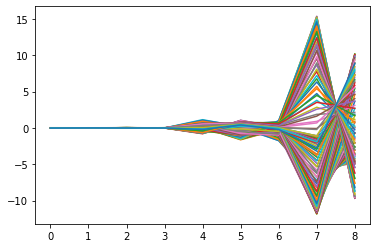

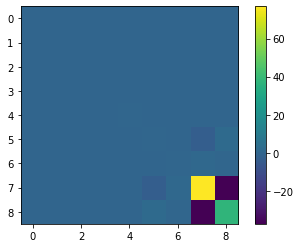

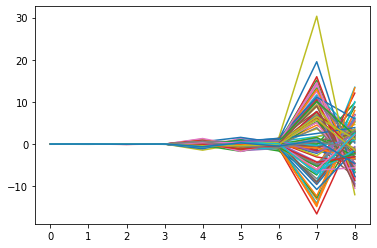

In [52]:
# Whitening
n_samples, dim = x_intern_1.shape

x_center = (x_intern_1 - x_intern_1.mean(0))
plt.plot(x_center.T)

plt.figure()
cov = x_center.T @ x_center / n_samples
plt.imshow(cov)
plt.colorbar()

eval, evec = np.linalg.eigh(cov)
x_center_gauss = np.random.multivariate_normal(np.zeros(dim), cov, size=n_samples)

plt.figure()
_ = plt.plot(x_center_gauss.T)


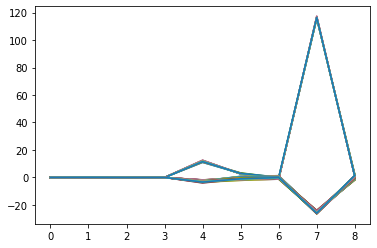

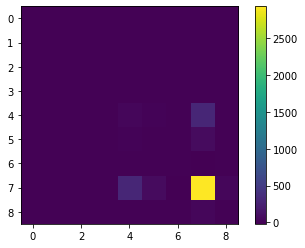

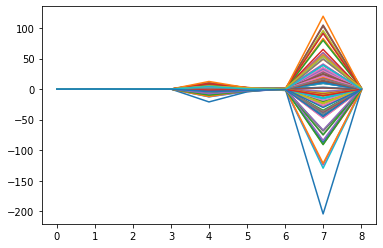

In [53]:
n_samples = x_intern_2.shape[0]
x_center = (x_intern_2 - x_intern_2.mean(0))
plt.plot(x_center.T)

plt.figure()
cov = x_center.T @ x_center / n_samples
plt.imshow(cov)
plt.colorbar()

eval, evec = np.linalg.eigh(cov)
x_center_gauss = np.random.multivariate_normal(np.zeros(dim), cov, size=n_samples)

plt.figure()
_ = plt.plot(x_center_gauss.T)

# 2. XYZ data

In [56]:
df = pd.read_csv(ceph_home + '/trajectories/isomer_1_xyz.csv')
x_xyz_1 = df.to_numpy()[:, 1:-1]
print(x_xyz_1.shape)
df.agg(['min', 'max', 'mean', 'std'], axis=0)

(101, 15)


,Unnamed: 0,x0,y0,z0,x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,y4,z4,energy
min,0.000000,6.816466,8.310447,9.499992,8.113981,10.653006,9.499309,9.482078,8.265564,9.168010,10.827082,10.656950,9.236230,12.029007,8.328001,8.801086,-5.420055
max,100.000000,6.905164,8.399951,9.981774,8.232770,10.706209,9.958435,9.534396,8.337918,9.710642,10.900789,10.707847,9.558527,12.188568,8.381443,9.499993,-5.410954
mean,50.000000,6.854228,8.357358,9.711738,8.165756,10.682294,9.704991,9.500803,8.302305,9.443040,10.861232,10.679744,9.468571,12.117981,8.354554,9.171638,-5.416426
std,29.300171,0.019946,0.021259,0.101564,0.028116,0.011207,0.124941,0.012443,0.018402,0.171107,0.017434,0.012290,0.078640,0.046931,0.011971,0.273908,0.002149


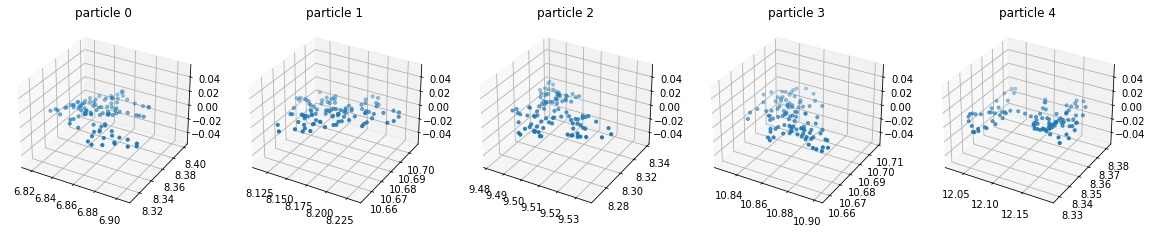

In [86]:

fig = plt.figure(figsize=(20,5))
for p in range(5):
    ax = fig.add_subplot(1, 5, p+1, projection='3d')
    ax.set_title('particle {:d}'.format(p))
    plt.scatter(x_xyz_1[:, 3 * p + 0], x_xyz_1[:, 3 * p + 1], x_xyz_1[:, 3 * p + 2])



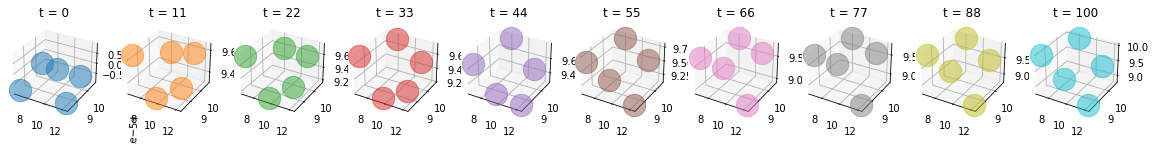

In [91]:
fig = plt.figure(figsize=(20,5))
for s, t in enumerate(np.linspace(0, 100, 10)):
    t = int(t)
    ax = fig.add_subplot(1, 10, s+1, projection='3d')
    c = ['C'+str(d) for d in range(10)]
    for p in range(5):
        ax.set_title('t = {:d}'.format(t))
        ax.scatter(x_xyz_1[t, 3 * p + 0], x_xyz_1[t, 3 * p + 1], x_xyz_1[t, 3 * p + 2], color=c[s], s=500, alpha=0.5)

In [88]:
df = pd.read_csv(ceph_home + '/trajectories/isomer_2_xyz.csv')
x_xyz_2 = df.to_numpy()[:, 1:-1]
df.agg(['min', 'max', 'mean', 'std'], axis=0)

,Unnamed: 0,x0,y0,z0,x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,y4,z4,energy
min,0.000000,9.442513,9.495451,8.362650,10.890528,8.889620,10.535095,7.951403,9.499998,10.544683,8.646902,7.231945,9.893916,9.499987,11.560424,9.968173,-5.070043
max,100.000000,9.546387,9.575971,8.419896,11.029370,9.500001,10.651305,8.114657,10.057105,10.660813,9.500013,7.420992,9.997536,10.381167,11.765201,10.068278,-5.064038
mean,50.000000,9.506928,9.518489,8.393581,10.976697,9.225101,10.601812,8.014503,9.759175,10.594824,9.107759,7.308345,9.954928,9.894113,11.688889,10.008179,-5.067505
std,29.300171,0.025543,0.021483,0.012749,0.033047,0.182260,0.028710,0.047487,0.165694,0.030505,0.255499,0.050617,0.027015,0.259843,0.054164,0.027142,0.001533


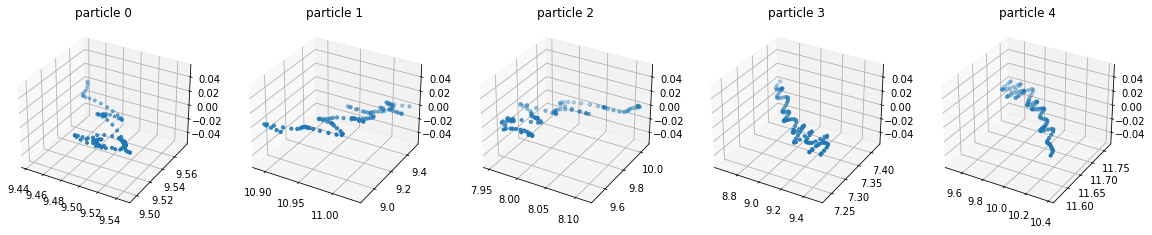

In [89]:

fig = plt.figure(figsize=(20,5))
for p in range(5):
    ax = fig.add_subplot(1, 5, p+1, projection='3d')
    ax.set_title('particle {:d}'.format(p))
    plt.scatter(x_xyz_2[:, 3 * p + 0], x_xyz_2[:, 3 * p + 1], x_xyz_2[:, 3 * p + 2])


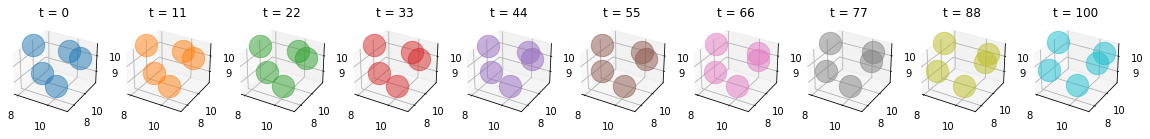

In [92]:
fig = plt.figure(figsize=(20,5))
for s, t in enumerate(np.linspace(0, 100, 10)):
    t = int(t)
    ax = fig.add_subplot(1, 10, s+1, projection='3d')
    c = ['C'+str(d) for d in range(10)]
    for p in range(5):
        ax.set_title('t = {:d}'.format(t))
        ax.scatter(x_xyz_2[t, 3 * p + 0], x_xyz_2[t, 3 * p + 1], x_xyz_2[t, 3 * p + 2], color=c[s], s=500, alpha=0.5)